# **I. Introduction**

---
## Background
Understanding our customer is a must in the crowded competition recent days. Maintaining and improving our customer could lengthen their lifetime period with higher quality transactions. This project focuses on the segmentation of credit card holders based on their behavioral patterns and distinct characteristics.

---
## Objective
The objective of this clustering is to identify the most effective, personalized strategies for increasing credit card usage frequency across different consumer segments.

---
## Dataset Background
The analysis utilizes an internal corporate dataset, which encompasses comprehensive consumer credit card transaction data collected over a six-month period.

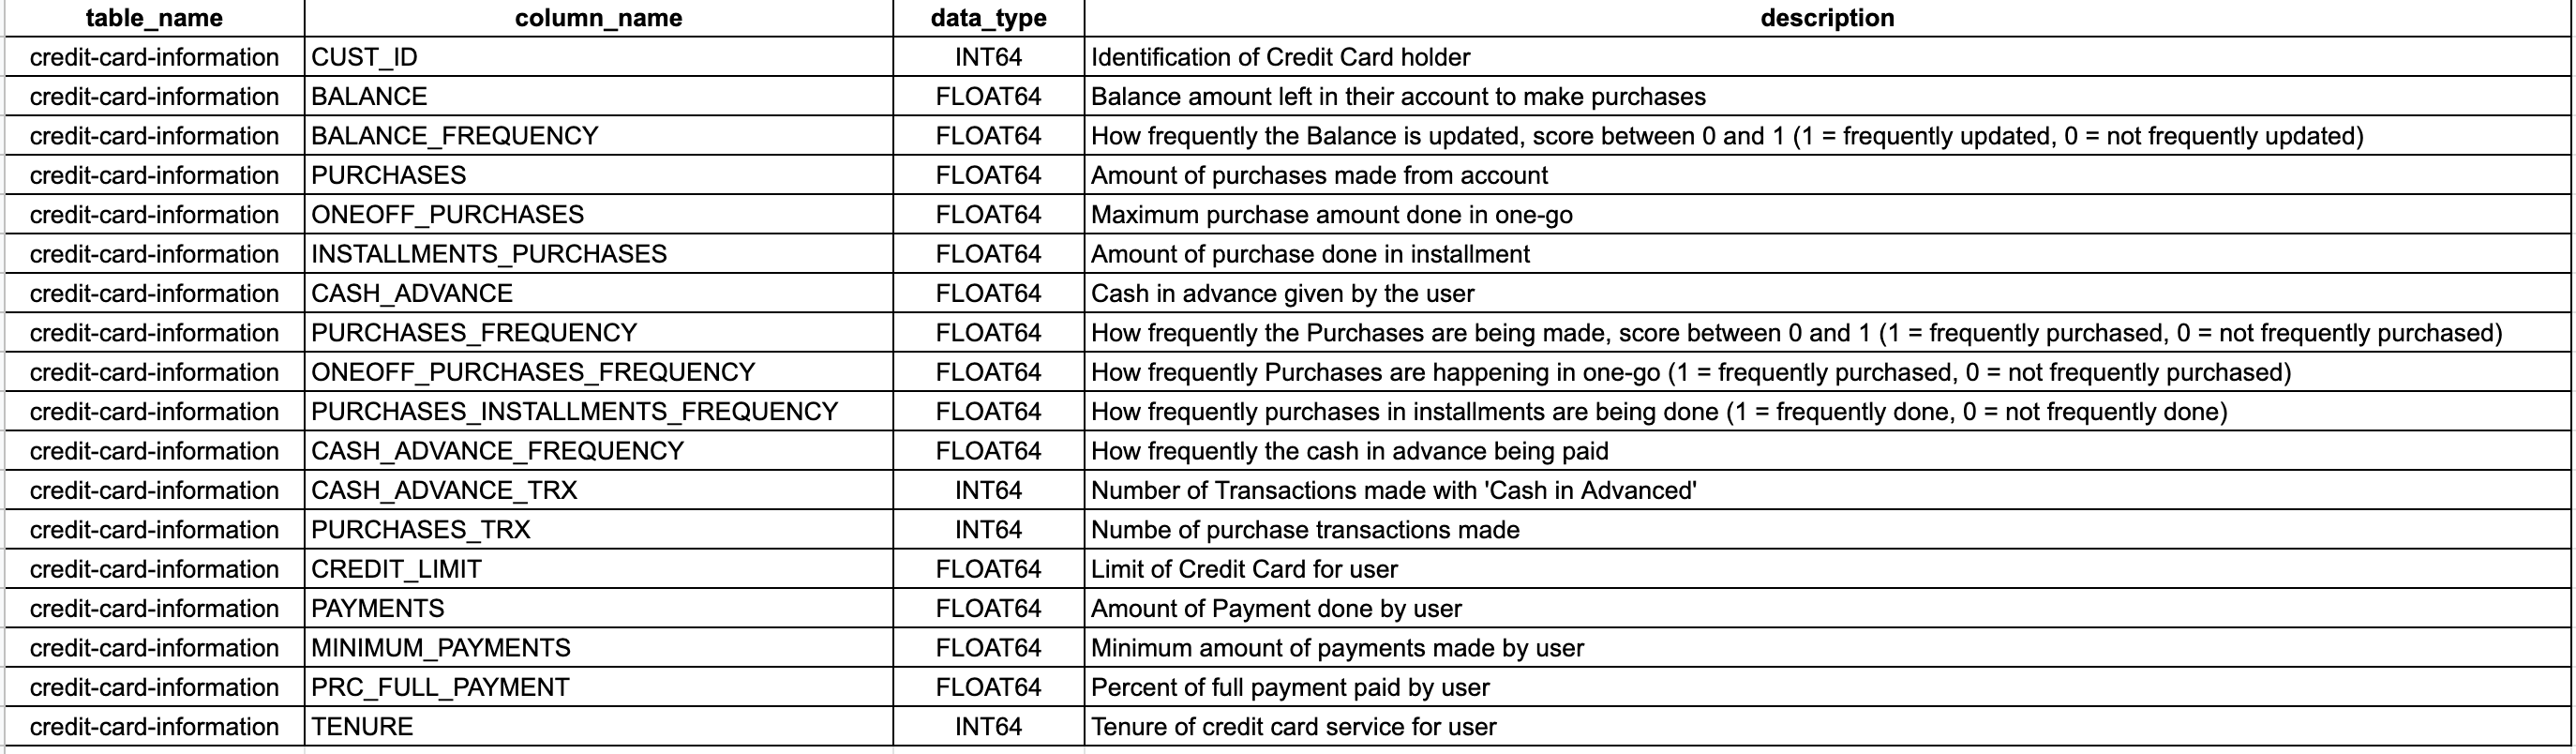

# **II. Import Libraries**

In [36]:
# Import Libraries
import pandas as pd                                                             # For Preprocessing
import numpy as np                                                              # For Numerical Operation
import seaborn as sns                                                           # For Visualization
import matplotlib.pyplot as plt                                                 # For Visualization
from sklearn.preprocessing import MinMaxScaler                                  # For Scaling and Encoding
from sklearn.impute import KNNImputer                                           # For Imputating Missing Value
from sklearn.compose import ColumnTransformer                                   # For Pipelining
from sklearn.preprocessing import FunctionTransformer                           # For Pipelining
from sklearn.pipeline import make_pipeline                                      # For Pipelining
from feature_engine.outliers import Winsorizer                                  # For Capping (Handling Outliers)
from sklearn.cluster import KMeans                                              # For Clustering
from sklearn.decomposition import PCA                                           # For Dimensionality Reduction
import matplotlib.cm as cm                                                      # For Visualization
from sklearn.metrics import silhouette_score,silhouette_samples                 # For Determining Number of Cluster
import dill                                                                     # For Reading Model

# **III. Data Loading**

In [37]:
# Load Data
df=pd.read_csv('dataset.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1987,21.881528,1.000000,89.04,89.04,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,2500.0,193.985335,96.885791,0.0,12
1,2973,36.567901,0.090909,1098.31,1098.31,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,4800.0,0.000000,NaN,0.0,12
2,4903,8.570991,0.272727,149.55,149.55,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,5000.0,447.377119,97.176376,0.0,12
3,7431,1409.206763,1.000000,143.50,143.50,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,3000.0,432.361276,300.764907,0.0,12
4,7979,810.739995,1.000000,86.90,86.90,0.0,0.0,0.083333,0.083333,0.0,0.0,0,1,7500.0,253.775702,210.961925,0.0,12


In [38]:
# Check data's summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           4475 non-null   int64  
 1   BALANCE                           4475 non-null   float64
 2   BALANCE_FREQUENCY                 4475 non-null   float64
 3   PURCHASES                         4475 non-null   float64
 4   ONEOFF_PURCHASES                  4475 non-null   float64
 5   INSTALLMENTS_PURCHASES            4475 non-null   float64
 6   CASH_ADVANCE                      4475 non-null   float64
 7   PURCHASES_FREQUENCY               4475 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        4475 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  4475 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            4475 non-null   float64
 11  CASH_ADVANCE_TRX                  4475 non-null   int64  
 12  PURCHA

From the information above, data type's features is correct

In [39]:
# Check duplicate row
df.duplicated().sum()

0

In [40]:
# Check standard missing values
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          0
PAYMENTS                              0
MINIMUM_PAYMENTS                    155
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [41]:
# Check data aggregation
df.describe()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4475.000000,4320.000000,4475.000000,4475.000000
mean,4475.000000,1563.205717,0.876933,1003.251343,596.369893,407.110215,984.288554,0.490579,0.202301,0.363886,0.136132,3.301229,14.929162,4494.878630,1740.075430,873.976757,0.150224,11.518212
std,2583.931114,2072.045789,0.238222,2060.034730,1653.425984,880.799744,2060.448056,0.402907,0.298203,0.397603,0.201036,7.134727,25.540814,3609.267706,2827.633858,2436.877272,0.289081,1.328925
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,2238.000000,124.432849,0.888889,39.560000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,376.913051,168.590144,0.000000,12.000000
50%,4475.000000,871.355430,1.000000,360.000000,45.650000,88.620000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,877.494612,313.980229,0.000000,12.000000
75%,6712.000000,2047.570799,1.000000,1102.420000,575.220000,455.885000,1138.887754,0.916667,0.250000,0.750000,0.250000,4.000000,17.000000,6500.000000,1911.596530,819.371080,0.125000,12.000000
max,8949.000000,18495.558550,1.000000,41050.400000,40624.060000,14686.100000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,347.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


From the information above, we can see that:
1. There is no negative value
2. BALANCE_FREQUENCY, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, PRC_FULL_PAYMENT columns are filled by ratio number (0-1). However, on CASH_ADVANCE_FREQUENCY, the max value is up to 1.5 so that we need check it further.
3. TENURE's column is a discrete column, so that we need further check


In [42]:
# Check "TENURE" discrete column or not
df['TENURE'].value_counts()

TENURE
12    3777
11     199
10     122
6      101
8       99
7       90
9       87
Name: count, dtype: int64

From the information above, this column is contained with discrete values. Therefore, we will scale it using MinMaxScaler since it has a relative distance and no likelihood to have normal distribution. If there is any likelihood having normal distribution, it should use StandardScaler.

In [43]:
# Check potential extreme outlier
df.sort_values(by='CASH_ADVANCE_FREQUENCY').tail(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3429,6539,2648.244646,1.0,0.00,0.00,0.00,10458.978150,0.000000,0.000000,0.000000,1.000000,123,0,4000.0,9818.531412,665.888853,0.000000,12
982,7677,6956.376540,1.0,11500.94,3091.01,8409.93,15133.532130,1.000000,1.000000,1.000000,1.000000,48,308,14000.0,20122.005450,1617.014574,0.166667,12
4370,5199,9601.071318,1.0,238.34,0.00,238.34,4809.119550,0.833333,0.000000,0.833333,1.000000,8,5,15000.0,1194.510762,1206.257247,0.000000,6
2976,4857,3688.371995,1.0,0.00,0.00,0.00,10746.545380,0.000000,0.000000,0.000000,1.000000,63,0,7000.0,10906.068460,1059.881395,0.083333,12
1969,2389,1917.895730,1.0,285.07,285.07,0.00,6084.858872,0.363636,0.363636,0.000000,1.090909,28,6,3000.0,5692.682993,556.449635,0.000000,11
717,4375,7801.511533,1.0,231.40,231.40,0.00,4109.465221,0.100000,0.100000,0.000000,1.100000,20,3,13500.0,1593.617739,1522.496755,0.000000,10
983,5727,5906.184924,1.0,141.80,141.80,0.00,1651.286918,0.125000,0.125000,0.000000,1.125000,12,2,10000.0,933.969974,919.289675,0.000000,8
2334,8127,3857.562230,1.0,0.00,0.00,0.00,2127.213754,0.000000,0.000000,0.000000,1.142857,26,0,5000.0,617.508991,538.396872,0.000000,7
631,5195,5656.069801,1.0,362.36,362.36,0.00,7240.433194,0.250000,0.250000,0.000000,1.250000,12,2,8000.0,683.421497,2036.877611,0.000000,8
2445,6407,3846.742530,1.0,0.00,0.00,0.00,1932.460679,0.000000,0.000000,0.000000,1.500000,18,0,5600.0,496.245836,538.346874,0.000000,6


From the information above, there are a few data valued more than 1. Those should be dropped.

In [44]:
# Drop extreme values
df = df[df['CASH_ADVANCE_FREQUENCY'] <= 1]

# **IV. Exploratory Data Analysis**

In [45]:
# Display column's names
df.columns.to_list()

['CUST_ID',
 'BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

In [46]:
# Simple Normality Check for Continous Columns
df[['BALANCE',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS']].agg(['mean','median','skew']).T

,mean,median,skew
BALANCE,1558.818441,869.947607,2.338836
PURCHASES,1004.369910,360.300000,7.067826
ONEOFF_PURCHASES,596.942188,45.450000,9.944849
INSTALLMENTS_PURCHASES,407.656793,89.370000,6.327382
CASH_ADVANCE,980.430871,0.000000,5.664124
CASH_ADVANCE_TRX,3.279705,0.000000,6.478210
PURCHASES_TRX,14.946297,7.000000,4.744940
CREDIT_LIMIT,4490.821631,3000.000000,1.501772
PAYMENTS,1740.170084,877.494612,5.747863
MINIMUM_PAYMENTS,873.775552,313.010299,14.661609


This skewness information will be the consideration on handling missing values and scaling

### 1. Is there a pattern between the influence of TENURE with PURCHAES, BALANCE or PAYMENTS?
a. TENURE and PURCHASES

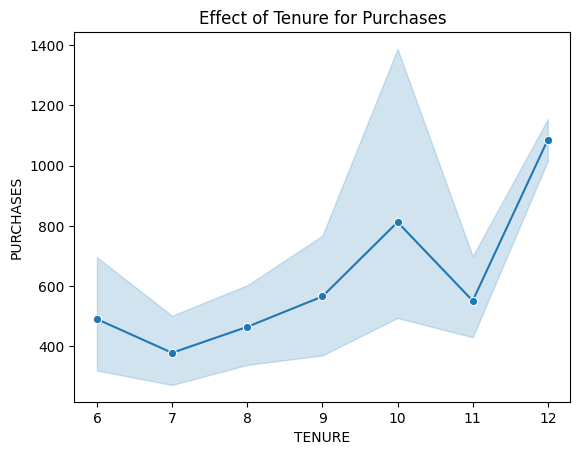

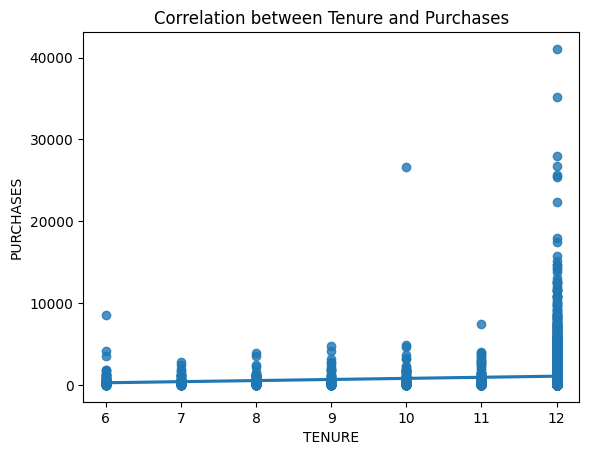

Correlation : 0.12488496631391127


In [47]:
# Effect of 'TENURE' for 'PURCHASES'
sns.lineplot(data=df,x='TENURE',y='PURCHASES', marker='o')
plt.title("Effect of Tenure for Purchases")
plt.show()

corr=df['TENURE'].corr(df['PURCHASES'], method='spearman')
sns.regplot(data=df,x='TENURE',y='PURCHASES')
plt.title("Correlation between Tenure and Purchases")
plt.show()
print(f'Correlation : {corr}')

From the information above, the correlation between TENURE and PURCHASES is too low. So we cannot apply different or special treatment for longest-registered customer, though the correlation is positive.

b. TENURE and BALANCE

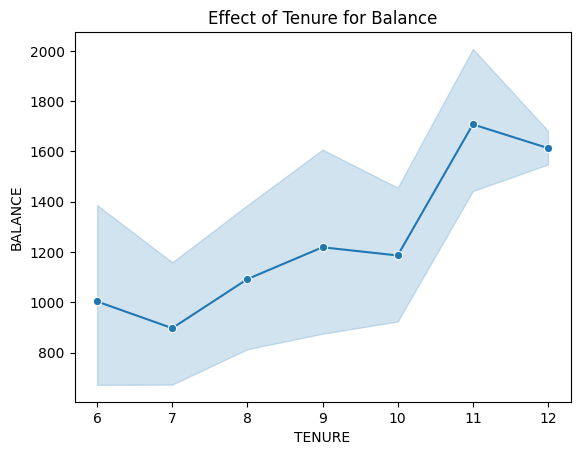

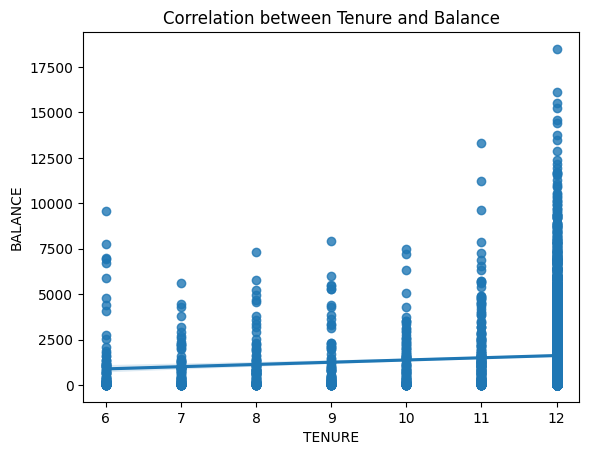

Correlation : 0.06650259579487969


In [48]:
# Effect of 'TENURE' for 'BALANCE'
sns.lineplot(data=df,x='TENURE',y='BALANCE', marker='o')
plt.title("Effect of Tenure for Balance")
plt.show()

# Correlation analysis
corr=df['TENURE'].corr(df['BALANCE'], method='spearman')
sns.regplot(data=df,x='TENURE',y='BALANCE')
plt.title("Correlation between Tenure and Balance")
plt.show()
print(f'Correlation : {corr}')

From the information above, the correlation between TENURE and BALANCE is too low. So we cannot apply different or special treatment for longest-registered customer, though the correlation is positive.

c. TENURE and PAYMENTS

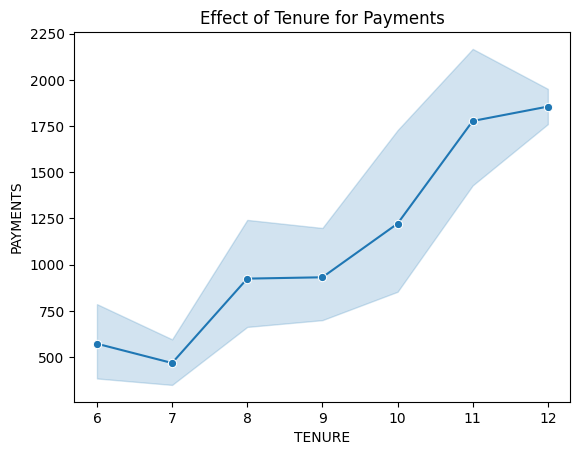

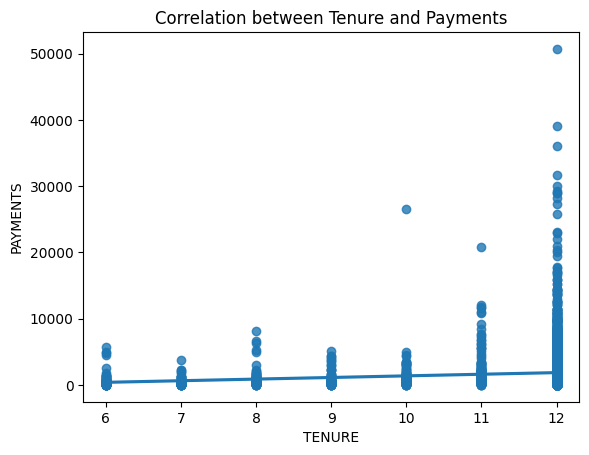

Correlation : 0.19970585969475935


In [49]:
# Effect of 'TENURE' for 'PAYMENTS'
sns.lineplot(data=df,x='TENURE',y='PAYMENTS', marker='o')
plt.title("Effect of Tenure for Payments")
plt.show()

# Correlation analysis
corr=df['TENURE'].corr(df['PAYMENTS'], method='spearman')
sns.regplot(data=df,x='TENURE',y='PAYMENTS')
plt.title("Correlation between Tenure and Payments")
plt.show()
print(f'Correlation : {corr}')

From the information above, the correlation between TENURE and PAYMENTS is too low. So we cannot apply different or special treatment for longest-registered customer, though the correlation is positive.


Regardless of low correlation between TENURE with PURCHASES, BALANCE, PAYMENTS, we can see customer with tenure 12 have highest PURCHASES, BALANCE, PAYMENTS. Therefore, we can do something interesting for customer with tenure 12 because they generate much money then other customers.

### 2. Is customer with Higher CREDIT_LIMIT tend to buy more?

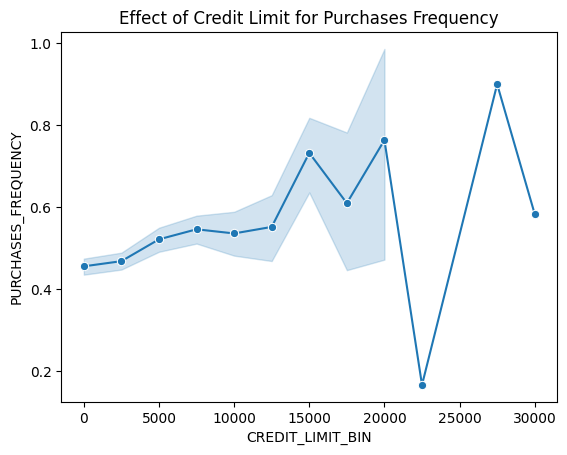

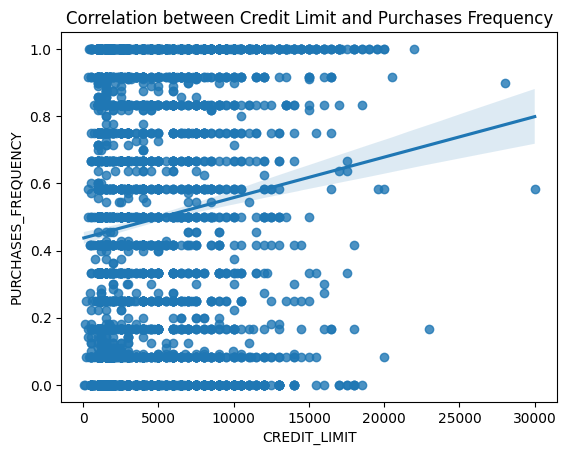

Correlation : 0.08605540312096882


In [50]:
# Effect of 'CREDIT_LIMIT' for 'PURCHASES_FREQUENCY'
df['CREDIT_LIMIT_BIN'] = (df['CREDIT_LIMIT'] // 2500) * 2500
sns.lineplot(data=df, x='CREDIT_LIMIT_BIN', y='PURCHASES_FREQUENCY', marker='o')
plt.title('Effect of Credit Limit for Purchases Frequency')
plt.show()

# Correlation analysis
corr=df['CREDIT_LIMIT'].corr(df['PURCHASES_FREQUENCY'], method='spearman')
sns.regplot(data=df,x='CREDIT_LIMIT',y='PURCHASES_FREQUENCY')
plt.title("Correlation between Credit Limit and Purchases Frequency")
plt.show()
print(f'Correlation : {corr}')

# Drop helper column
df=df.drop(['CREDIT_LIMIT_BIN'], axis=1)

From the information above, the correlation between Credit Limit and Purchases Frequency is too low. So we cannot get valuable insight, though the correlation is positive.

# **V. Feature Engineering**

---
## Data Preprocessing

In [51]:
# Check symptom of NaN values in MINIMUM_PAYMENTS is correlated with PAYMENTS
df.sort_values(by='PAYMENTS',ascending=False).tail(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2499,2815,116.654149,0.272727,907.00,907.00,0.0,273.558033,0.250000,0.250000,0.000000,0.083333,1,8,5000.0,0.0,NaN,0.0,12
2509,5999,25.998899,0.111111,0.00,0.00,0.0,466.387778,0.000000,0.000000,0.000000,0.111111,1,0,4000.0,0.0,NaN,0.0,9
911,5951,0.000000,0.000000,240.10,0.00,240.1,0.000000,0.583333,0.000000,0.583333,0.000000,0,7,2500.0,0.0,NaN,0.0,12
2530,6821,4223.832142,1.000000,0.00,0.00,0.0,3305.855177,0.000000,0.000000,0.000000,0.500000,18,0,4500.0,0.0,NaN,0.0,12
2539,2941,9.128510,0.181818,80.06,80.06,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1600.0,0.0,NaN,0.0,12
942,8361,141.656741,0.181818,1109.83,1109.83,0.0,379.155222,0.166667,0.166667,0.000000,0.083333,1,3,1200.0,0.0,NaN,0.0,12
939,523,2676.253141,0.909091,0.00,0.00,0.0,2832.570661,0.000000,0.000000,0.000000,0.083333,2,0,3000.0,0.0,NaN,0.0,12
2546,917,8.285344,0.142857,72.52,72.52,0.0,0.000000,0.142857,0.142857,0.000000,0.000000,0,1,3000.0,0.0,NaN,0.0,7
3660,125,71.310815,0.090909,0.00,0.00,0.0,1849.578078,0.000000,0.000000,0.000000,0.083333,1,0,6000.0,0.0,NaN,0.0,12
1787,6207,147.418569,0.181818,1074.00,1074.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,2,5500.0,0.0,NaN,0.0,12


In [52]:
# Check symptom more detail
df[~((df['PAYMENTS'] == 0) & (df['MINIMUM_PAYMENTS'].isna()))].sort_values(by='PAYMENTS').tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2466,8049,2980.054695,0.818182,26784.62,26514.32,270.30,0.00000,0.583333,0.500000,0.083333,0.0,0,33,30000.0,30029.01496,11853.796130,0.750000,12
1778,533,4419.302940,1.000000,12551.95,10901.24,1650.71,14896.54051,1.000000,0.666667,1.000000,0.5,19,122,17000.0,31698.41902,1448.585054,0.416667,12
916,7855,13479.288210,1.000000,41050.40,40624.06,426.34,0.00000,0.833333,0.666667,0.416667,0.0,0,157,17000.0,36066.75068,15914.484620,0.083333,12
2906,5377,10905.053810,1.000000,431.93,133.50,298.43,47137.21176,0.583333,0.250000,0.500000,1.0,123,21,19600.0,39048.59762,5394.173671,0.000000,12
1344,5757,1268.809031,0.272727,17945.00,17945.00,0.00,0.00000,0.166667,0.166667,0.000000,0.0,0,3,18000.0,50721.48336,1149.747342,0.000000,12


From the information above, there is correlation of NaN values in MINIMUM_PAYMENTS with PAYMENTS. So we will drop those columns. For NaN values in MINIMUM_PAYMENTS but having values on PAYMENTS, we will impute with KNN algorithm

In [53]:
# Drop row with PAYMENTS is 0 and MINIMUM_PAYMENTS is NaN
df = df[~((df['PAYMENTS'] == 0) & (df['MINIMUM_PAYMENTS'].isna()))]

In [54]:
# Grouping columns based on characteristics
ratio_or_discrete_cols=['TENURE', 'BALANCE_FREQUENCY','PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']
continous_cols = ['BALANCE','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE','CASH_ADVANCE_TRX','PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS']

Grouping above based on what feature engineering we will do namely:
1. For ratio and discrete columns, we will do missing value handling (if exist) and scaling using MinMaxScaler. This scaler is choosen since the columns already range between 0-1 and for 'TENURE', it has relative distance between each datum.
2. For continous cols, because all columns are skew, we will do capping (IQR*3). Since on ratio or discrete columns we use MinMaxScaler, we would use Log Transformation before applying MinMaxScaler. This consideration emerges because we will use K-Means which uses Euclidean Distance so that using same scaler is crucial.

---
## Feature Transformation

In [ ]:
# Function for dropping ID columns
def drop (df):
    return df.drop(columns=['CUST_ID'], axis=1)
drop_column=FunctionTransformer(drop)                              

# Imputation Tool
imputer = KNNImputer(n_neighbors=5)

# Feature engineering for ratio_or_discrete_cols
non_capping_pipe = make_pipeline(imputer.set_output(transform="pandas"),
                                 MinMaxScaler())      

# Feature engineering for continous_cols
capping_pipe = make_pipeline(Winsorizer(capping_method='iqr',                       
                                        tail='both',
                                        fold=3,
                                        missing_values='ignore'),
                            imputer.set_output(transform="pandas"),
                            FunctionTransformer(np.log1p),
                            MinMaxScaler())    

# Pipeline for Feature engineering
preprocessing_pipeline = ColumnTransformer([
    ('pipe_non_capping', non_capping_pipe, ratio_or_discrete_cols),
    ('pipe_capping_cols', capping_pipe, continous_cols)], remainder='passthrough')

### Dimensionality Reduction

Text(0, 0.5, 'Eigenvalues')

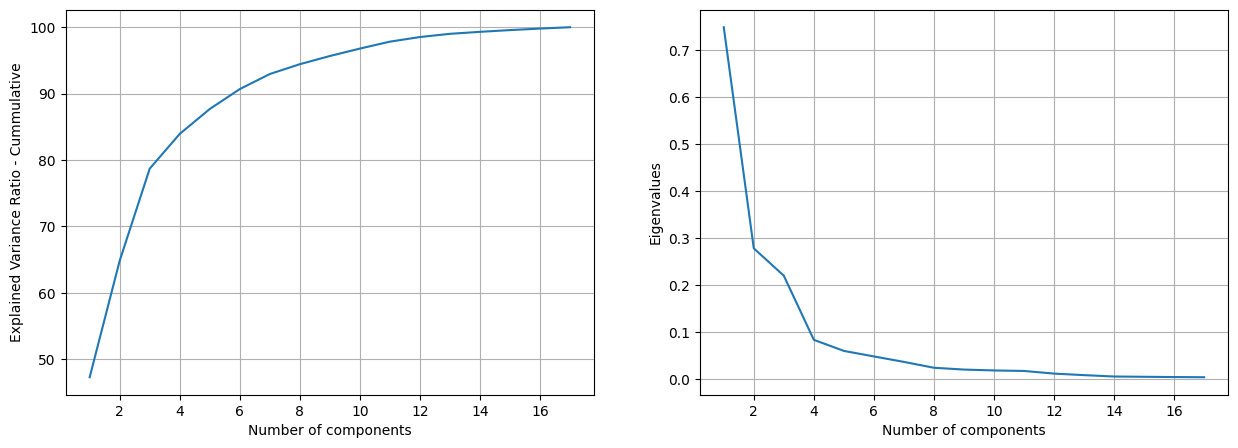

In [56]:
# Implement PCA
pca_check=PCA()
pipe_pca_check = make_pipeline(drop_column, preprocessing_pipeline, pca_check)
pca_check_result = pipe_pca_check.fit(df)
fitted_pca = pca_check_result[-1]

# Plot the Cummulative of Explained Variance Ratio
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.grid()
plt.plot(range(1, 18), np.cumsum(fitted_pca.explained_variance_ratio_ * 100))
plt.xlabel('Number of components')
plt.ylabel('Explained Variance Ratio - Cummulative')

# Plot the Eigenvalues
plt.subplot(1, 2, 2)
plt.grid()
plt.plot(range(1, 18), fitted_pca.explained_variance_ )
plt.xlabel('Number of components')
plt.ylabel('Eigenvalues')

In [57]:
# Determine PCA contained 95% information
pca_train = PCA(n_components=0.95)

We want to retain 95% data. From this consideration, we can see 95% variance ratio will contain with 9 components and they have eigenvalues less than 0.1

In [58]:
# Pipeline and Train for Determining Number of Cluster
cluster_num_check = make_pipeline(drop_column, preprocessing_pipeline, pca_train)
df_cluster_check = cluster_num_check.fit_transform(df)

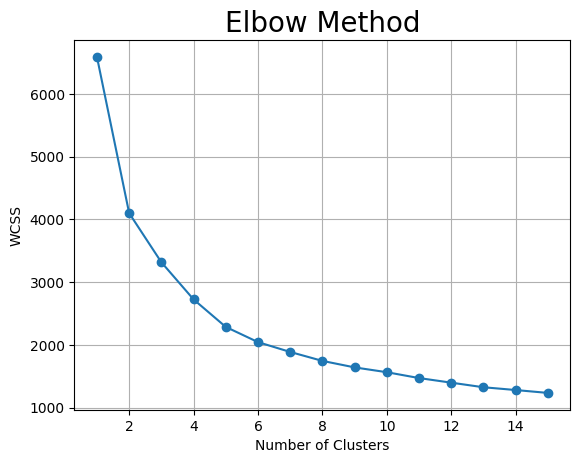

In [59]:
# Find the optimal number of clusters using Elbow Method

# Calculate WCSS
wcss = []
random_state = 10
max_cluster = 15
for i in range(1, max_cluster+1):
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                max_iter = 300,
                n_init = 10,
                random_state = random_state)
    km.fit(df_cluster_check)
    wcss.append(km.inertia_)

# Visualization of Elbow Method
plt.plot(range(1, max_cluster+1), wcss, marker ="o")
plt.grid()
plt.title('Elbow Method', fontsize = 20)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

From the information above, there is elbow ranging from 2-6 clusters. For final decision, we should review the sillhoute score.

In [60]:
# Function to create Silhouette Plot
def plot_silhouette(range_n_clusters, X, random_state):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 4)

        # The 1st subplot is the silhouette plot
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters = n_clusters, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        silhouette_avg = silhouette_score(X, cluster_labels)
        print("For n_clusters =", n_clusters,
              "The average silhouette_score is :", silhouette_avg)

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                    c=colors, edgecolor='k')

        # Labeling the clusters
        centers = clusterer.cluster_centers_

        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                      "with n_clusters = %d" % n_clusters),
                     fontsize=14, fontweight='bold')

For n_clusters = 2 The average silhouette_score is : 0.3402676806697333
For n_clusters = 3 The average silhouette_score is : 0.2954074661748336
For n_clusters = 4 The average silhouette_score is : 0.32301323006683086
For n_clusters = 5 The average silhouette_score is : 0.3359779498023013
For n_clusters = 6 The average silhouette_score is : 0.3248221521704321
For n_clusters = 7 The average silhouette_score is : 0.31670292910861164
For n_clusters = 8 The average silhouette_score is : 0.3151645792033121
For n_clusters = 9 The average silhouette_score is : 0.32043816426205624
For n_clusters = 10 The average silhouette_score is : 0.3192238231980421
For n_clusters = 11 The average silhouette_score is : 0.3196887832581424
For n_clusters = 12 The average silhouette_score is : 0.26452358375626045
For n_clusters = 13 The average silhouette_score is : 0.26850097384301824
For n_clusters = 14 The average silhouette_score is : 0.2633269530071171


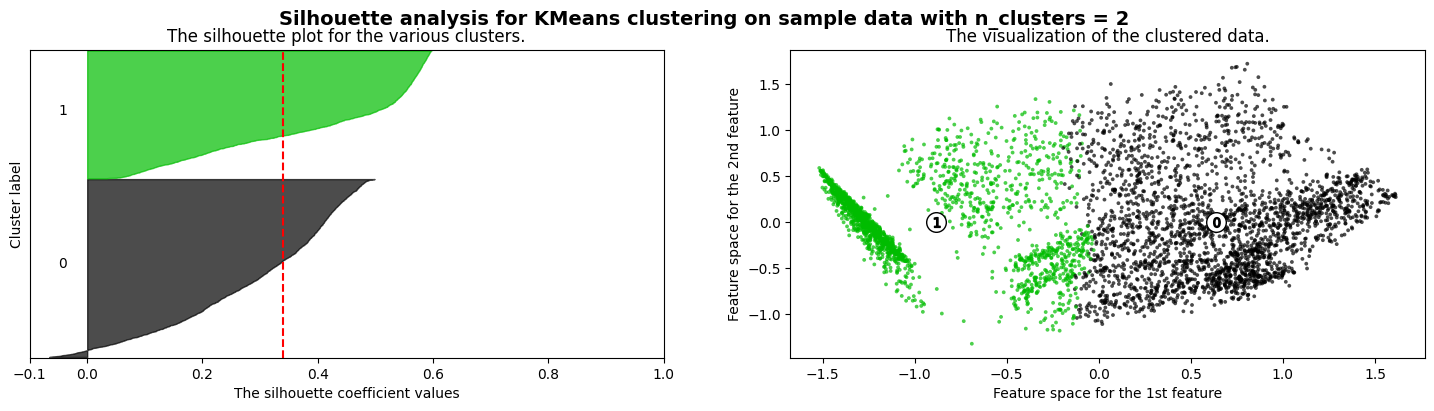

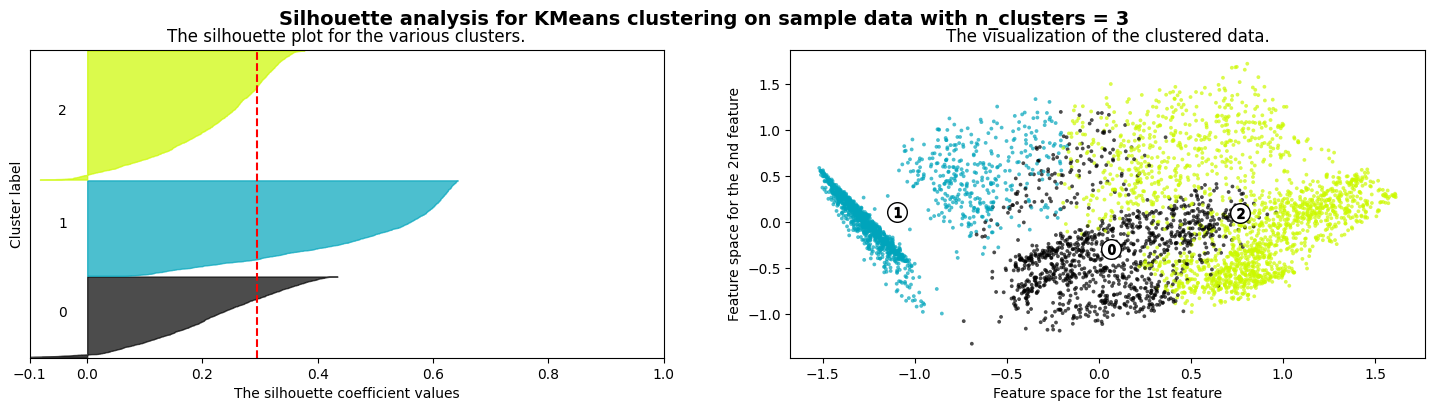

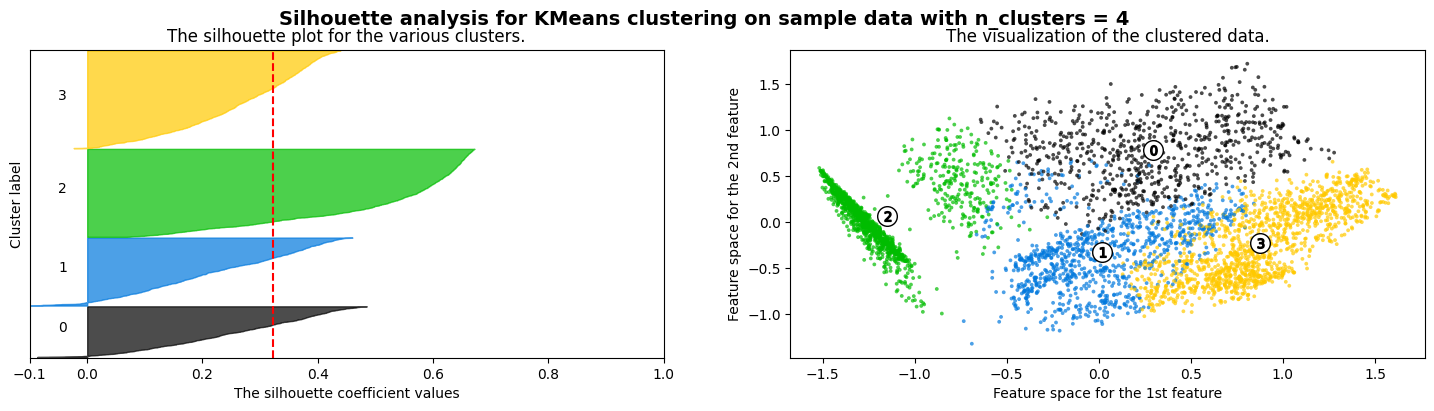

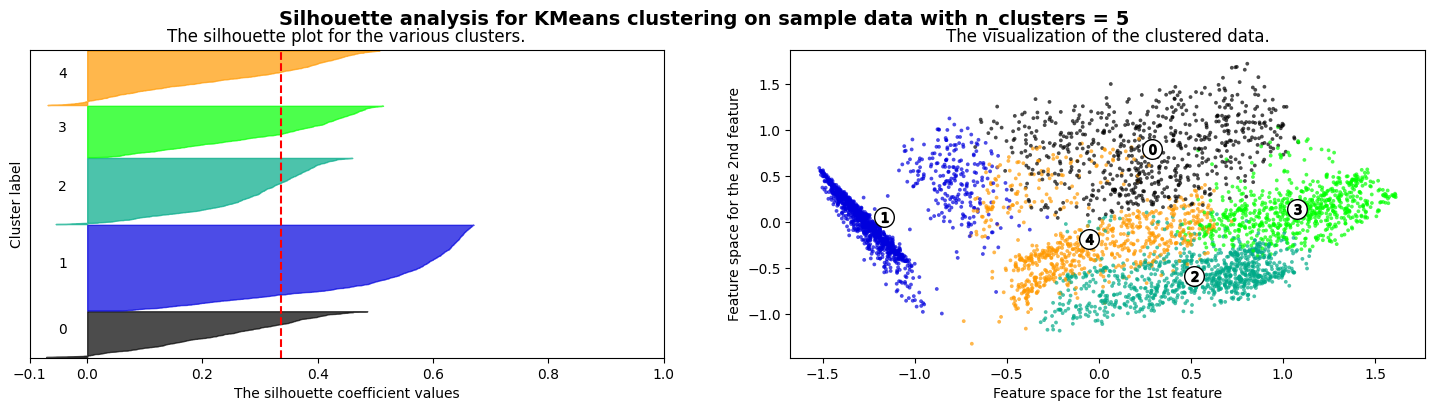

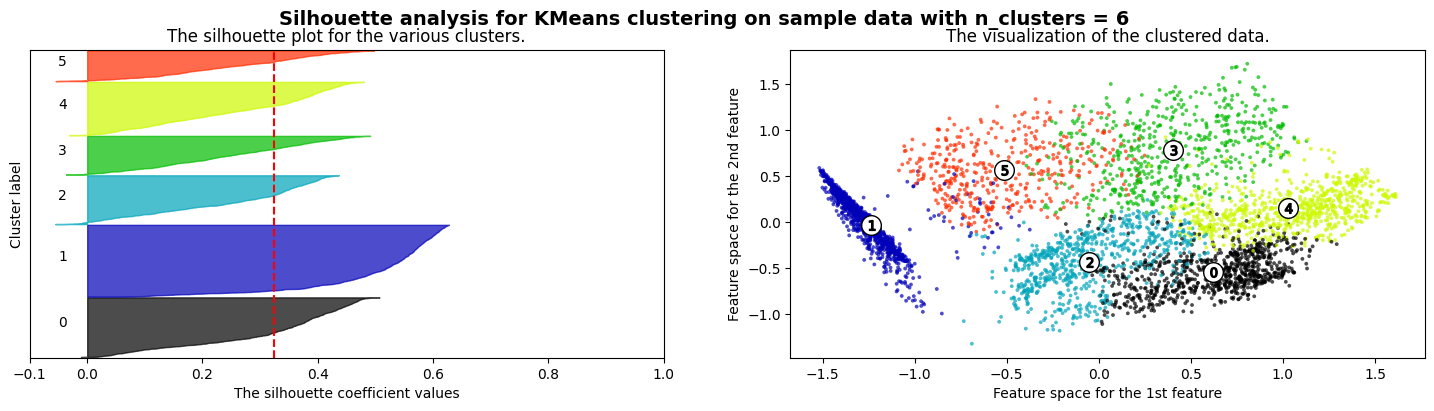

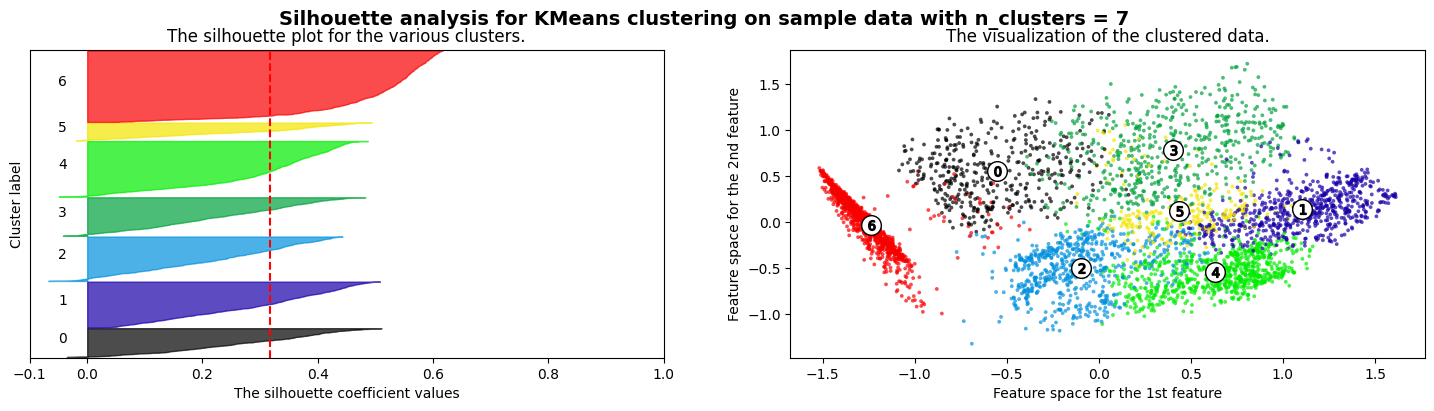

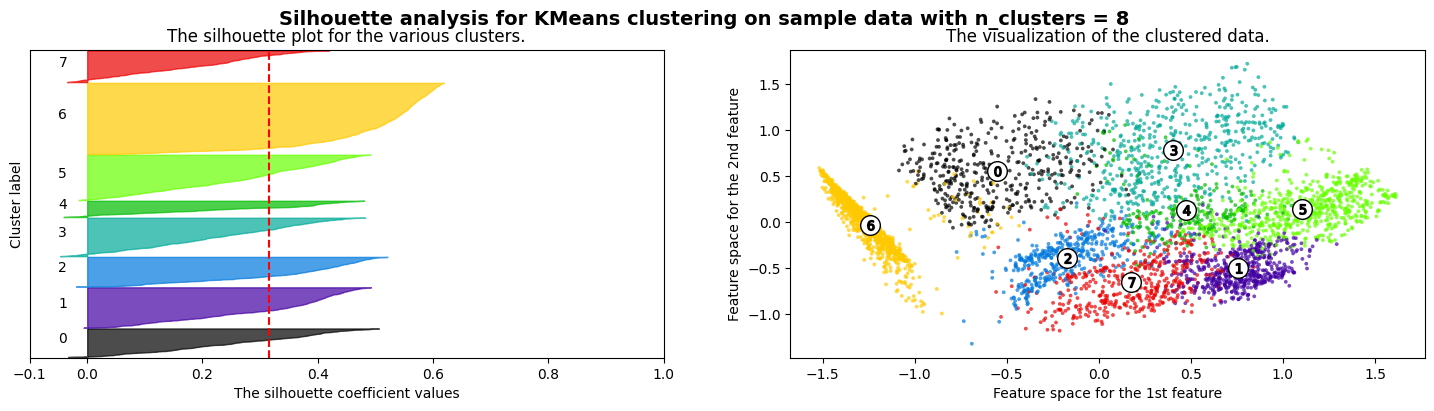

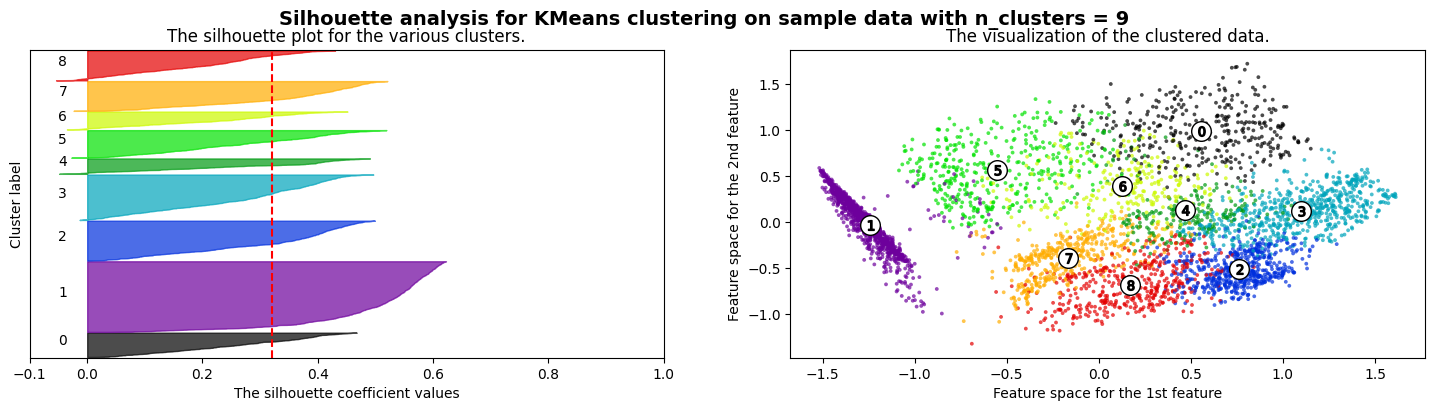

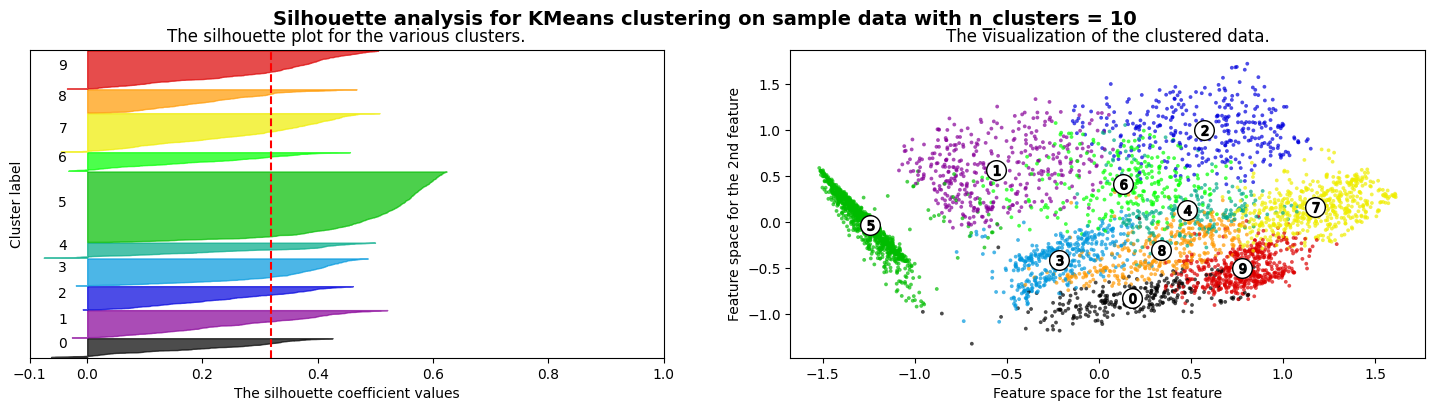

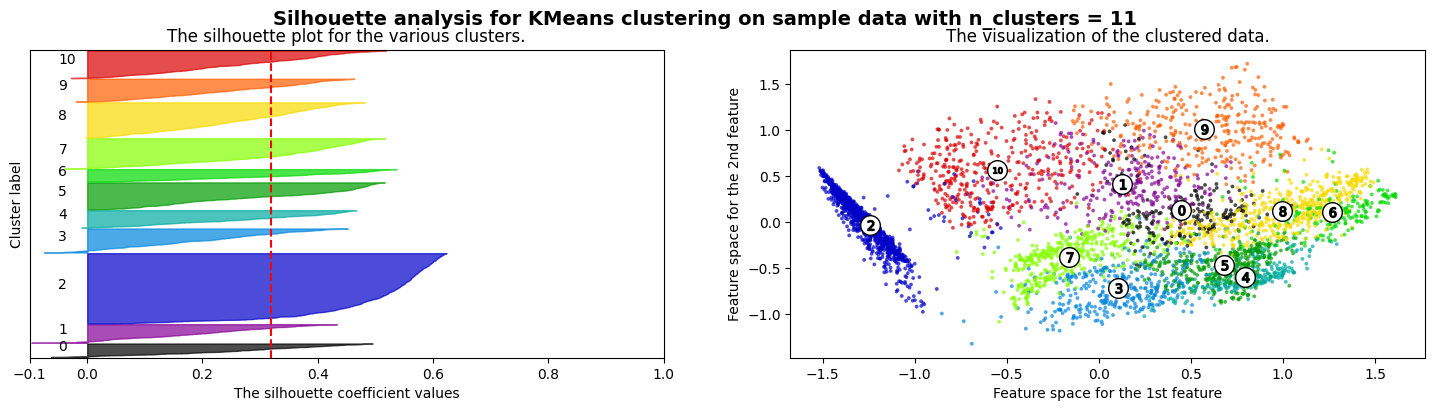

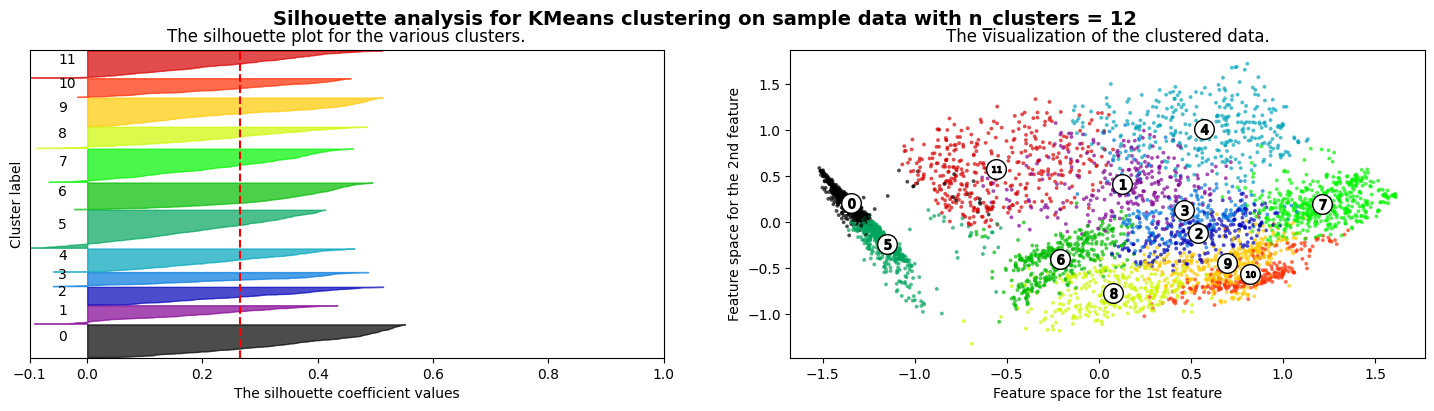

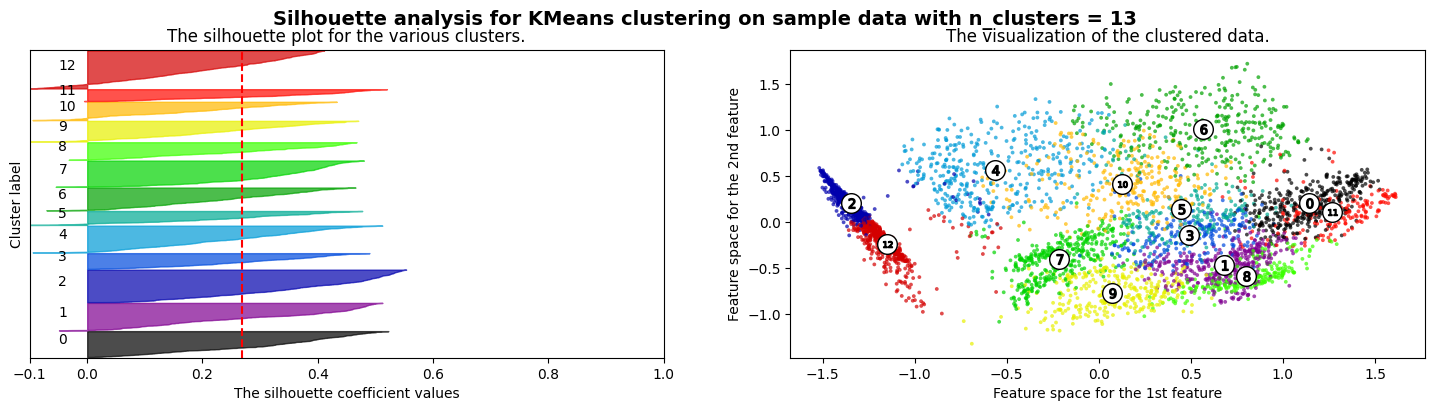

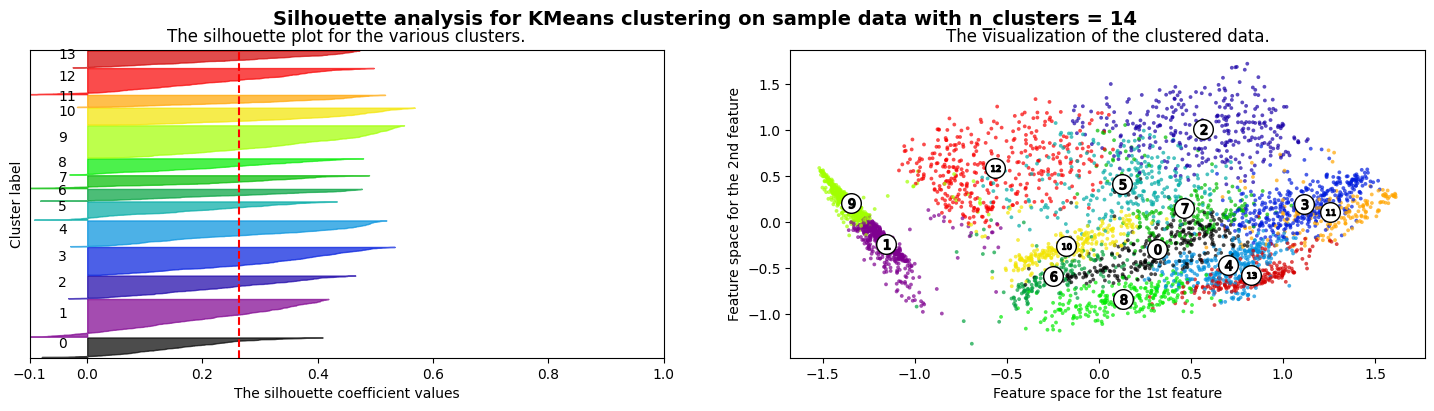

In [61]:
# Display the Silhouette Score and Plot Silhouette Plot
plot_silhouette(range(2, max_cluster), df_cluster_check, random_state)

From the information above, the highest score is for 2 clusters and 5 clusters. These align with the elbow method ranging from 2-6 clusters. For better segmentation, we choose 5 cluster for more personalized insight.

# **VI. Model Definition**

This project will cluster credit card's customer using K-Means algorithm. This algorithm will be used because we want to deem all data without ignoring them as noises. For detemining number of cluster, we have used Elbow Method and Sillhoute and detemined to use 5 clusters.

In [62]:
# Define Model
km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)

# **VII. Model Training**

In [63]:
# Define Trained Model
km_train = make_pipeline(drop_column, preprocessing_pipeline, pca_train, km)

# Train Model
pred = km_train.fit_predict(df)
pred

array([4, 4, 4, ..., 1, 1, 4])

# **VIII. Model Evaluation**

In [64]:
# Prepare Dataset
df_result=df.copy()
df_result=pd.DataFrame(imputer.fit_transform(df_result))

# Input Result into Dataset
df_result['CLUSTER'] = pred
df_result.to_csv('deployment/final_dataset.csv')
df_result.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CLUSTER
0,1987.0,21.881528,1.000000,89.04,89.04,0.00,0.0,0.083333,0.083333,0.000000,0.0,0.0,1.0,2500.0,193.985335,96.885791,0.0,12.0,4
2,4903.0,8.570991,0.272727,149.55,149.55,0.00,0.0,0.083333,0.083333,0.000000,0.0,0.0,1.0,5000.0,447.377119,97.176376,0.0,12.0,4
3,7431.0,1409.206763,1.000000,143.50,143.50,0.00,0.0,0.083333,0.083333,0.000000,0.0,0.0,1.0,3000.0,432.361276,300.764907,0.0,12.0,4
4,7979.0,810.739995,1.000000,86.90,86.90,0.00,0.0,0.083333,0.083333,0.000000,0.0,0.0,1.0,7500.0,253.775702,210.961925,0.0,12.0,4
5,2279.0,558.476701,1.000000,630.03,630.03,0.00,0.0,0.090909,0.090909,0.000000,0.0,0.0,1.0,5500.0,426.092563,213.369694,0.0,11.0,4
6,4049.0,1714.896284,1.000000,2000.00,2000.00,0.00,0.0,0.111111,0.111111,0.000000,0.0,0.0,1.0,2000.0,448.300443,348.836471,0.0,9.0,4
7,133.0,271.051660,0.909091,86.00,0.00,86.00,0.0,0.166667,0.000000,0.166667,0.0,0.0,2.0,1000.0,442.141178,2863.640612,0.0,12.0,2
8,2185.0,98.364739,0.181818,65.00,0.00,65.00,0.0,0.166667,0.000000,0.166667,0.0,0.0,2.0,1200.0,718.794328,53.655347,0.0,12.0,2
9,2891.0,907.371097,1.000000,55.65,0.00,55.65,0.0,0.166667,0.000000,0.166667,0.0,0.0,3.0,1000.0,416.818116,603.735158,0.0,12.0,2
10,703.0,44.539341,0.363636,94.30,71.80,22.50,0.0,0.250000,0.083333,0.250000,0.0,0.0,4.0,2500.0,940.026302,147.851745,0.0,12.0,4


In [65]:
# For deployment EDA
featured_data = pd.DataFrame(df_cluster_check)
featured_data.to_csv('deployment/featured_data.csv')

<Axes: >

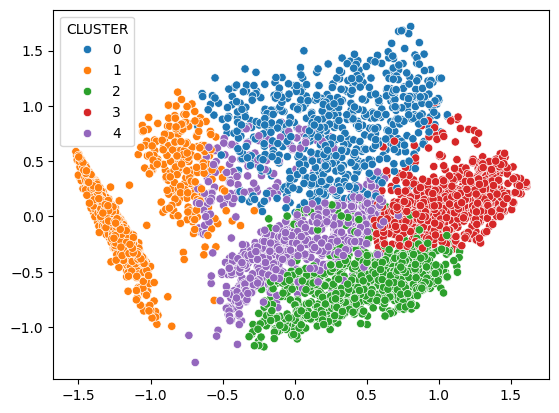

In [66]:
# Cluster visualization in 2D
pca_2d = PCA(n_components=2)
pca_2d.fit(df_cluster_check)

sales_scaled_pca_2d = pca_2d.fit_transform(df_cluster_check)

sns.scatterplot(x=sales_scaled_pca_2d[:,0], y=sales_scaled_pca_2d[:,1], hue=df_result['CLUSTER'], palette='tab10')

In [67]:
# Define columns' list without CLUSTER and CUST_ID
cols = df_result.drop(columns=['CLUSTER','CUST_ID']).columns.tolist()

# Determine mean as default aggregation function
agg_dict = {col: 'mean' for col in cols}

# Adjust for TENURE using median because it is discrete column
if 'TENURE' in agg_dict:
    agg_dict['TENURE'] = 'median'

# Make table for aggregation value
profil_cluster = df_result.groupby('CLUSTER').agg(agg_dict)
profil_cluster

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CLUSTER,,,,,,,,,,,,,,,,,
0,3083.981362,0.973839,1583.037565,854.696119,728.341446,2439.791488,0.778975,0.317668,0.611915,0.323642,8.592085,28.076104,5642.389650,2871.327564,1487.696799,0.046145,12.0
1,2286.650461,0.907521,38.714516,35.554589,3.204451,2104.910203,0.026421,0.020324,0.005639,0.286490,6.854353,0.393816,4227.641344,1711.896713,1046.343003,0.039486,12.0
2,374.549559,0.805943,536.295353,8.351960,528.964468,10.325013,0.721389,0.008013,0.681305,0.003776,0.047418,11.792413,3128.904163,776.588948,685.421166,0.308731,12.0
3,1353.045416,0.971742,3039.695875,1951.091655,1088.604220,14.319200,0.909642,0.556772,0.712705,0.005136,0.061058,41.879240,6042.062415,2827.166369,673.747420,0.298371,12.0
4,899.457707,0.803173,779.047905,750.959259,28.088646,119.846989,0.339123,0.307317,0.035369,0.027302,0.394636,6.638570,4192.567824,1233.502309,468.649340,0.102836,12.0


From analyzing all feature, for simplifying analysis, we would take more attention for these features:
 - BALANCE
 - PRC FULL PAYMENT
 - ONEOFF vs INSTALLMENT vs CASH ADVANCED

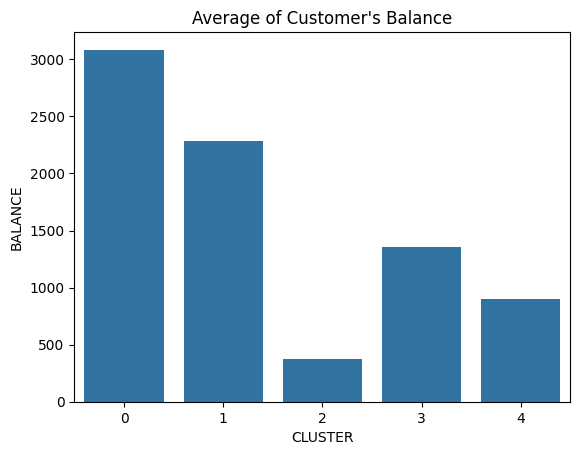

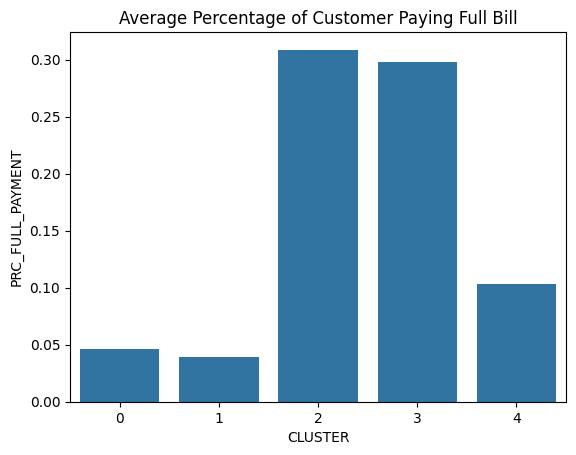

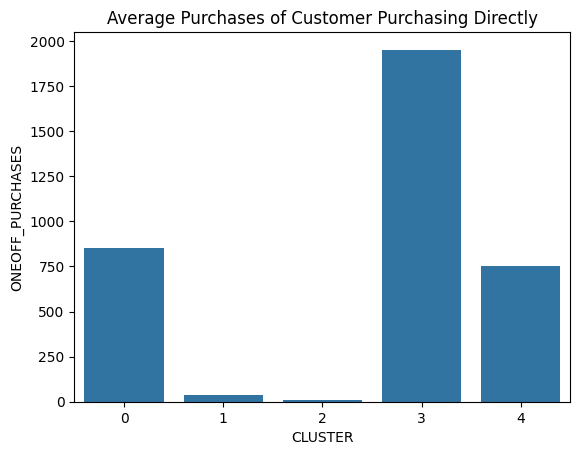

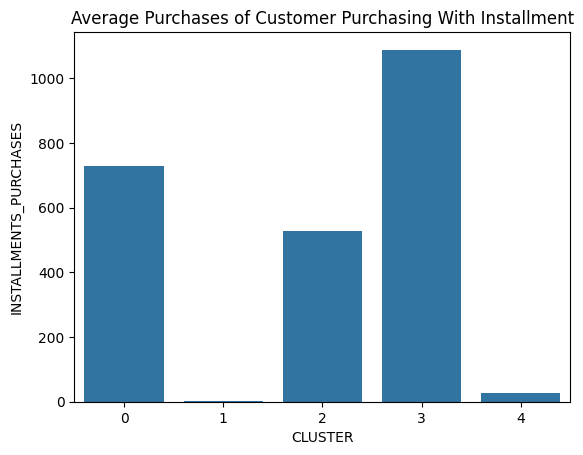

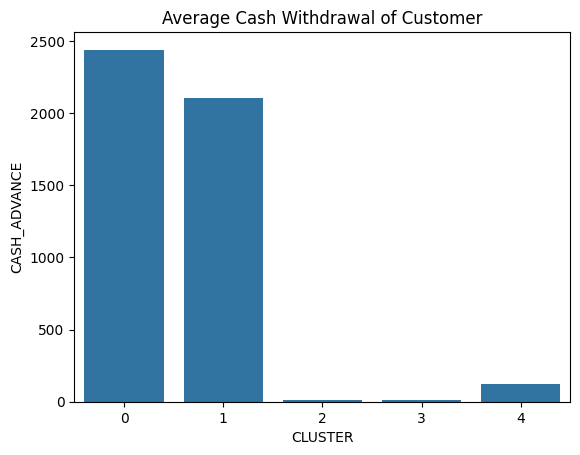

In [68]:
# Visualize BALANCE
sns.barplot(x=profil_cluster.index, y=profil_cluster['BALANCE'])
plt.title("Average of Customer's Balance")
plt.show()

# Visualize PRC_FULL_PAYMENT
sns.barplot(x=profil_cluster.index, y=profil_cluster['PRC_FULL_PAYMENT'])
plt.title('Average Percentage of Customer Paying Full Bill')
plt.show()

# Visualize ONEOFF_PURCHASES
sns.barplot(x=profil_cluster.index, y=profil_cluster['ONEOFF_PURCHASES'])
plt.title('Average Purchases of Customer Purchasing Directly')
plt.show()

# Visualize INSTALLMENTS_PURCHASES
sns.barplot(x=profil_cluster.index, y=profil_cluster['INSTALLMENTS_PURCHASES'])
plt.title('Average Purchases of Customer Purchasing With Installment')
plt.show()

# Visualize CASH_ADVANCE
sns.barplot(x=profil_cluster.index, y=profil_cluster['CASH_ADVANCE'])
plt.title('Average Cash Withdrawal of Customer')
plt.show()

In [69]:
# Make new columns for total expense
profil_cluster['TOTAL_EXPENSE'] = profil_cluster['ONEOFF_PURCHASES'] + profil_cluster['INSTALLMENTS_PURCHASES'] + profil_cluster['CASH_ADVANCE']

# Make new columns for displaying proportion of spend behavior
profil_cluster['% of ONEOFF_PURCHASES'] = (profil_cluster['ONEOFF_PURCHASES'] / profil_cluster['TOTAL_EXPENSE']) * 100
profil_cluster['% of INSTALLMENTS_PURCHASES'] = (profil_cluster['INSTALLMENTS_PURCHASES'] / profil_cluster['TOTAL_EXPENSE']) * 100
profil_cluster['% of CASH_ADVANCE'] = (profil_cluster['CASH_ADVANCE'] / profil_cluster['TOTAL_EXPENSE']) * 100

# Define columns to display by table
result_cols = [
    'BALANCE', 'PRC_FULL_PAYMENT', 'TOTAL_EXPENSE', 
    '% of ONEOFF_PURCHASES', '% of INSTALLMENTS_PURCHASES', '% of CASH_ADVANCE']

profil_analysis = profil_cluster[result_cols]
profil_analysis

,BALANCE,PRC_FULL_PAYMENT,TOTAL_EXPENSE,% of ONEOFF_PURCHASES,% of INSTALLMENTS_PURCHASES,% of CASH_ADVANCE
CLUSTER,,,,,,
0,3083.981362,0.046145,4022.829052,21.246146,18.105205,60.648649
1,2286.650461,0.039486,2143.669243,1.658586,0.149484,98.191930
2,374.549559,0.308731,547.641440,1.525078,96.589562,1.885360
3,1353.045416,0.298371,3054.015075,63.886117,35.645018,0.468865
4,899.457707,0.102836,898.894895,83.542499,3.124798,13.332703


From the information above, we can take insights that:
1. Cluster 0 (Segment A) : High balance, weak ability to pay bills with the largest nominal amount in the form of cash withdrawals
2. Cluster 1 (Segment B) : High balance (debt), weak ability to pay bills with almost all in the form of cash withdrawals
3. Cluster 2 (Segment C) : Low balance, strong ability to pay bills with the largest nominal amount in the form of installment purchases
4. Cluster 3 (Segment D) : Moderate balance, strong ability to pay bills with the largest nominal amount in the form of direct purchases
5. Cluster 4 (Segment E) : Low balance, moderate ability to pay bills wwith the largest nominal amount in the form of direct purchases

# **IX. Model Saving**

In [70]:
# Saving Model
with open('deployment/kmeans_model.pkl', 'wb') as a:
    dill.dump(km_train, a)